# NumCompute Assignment 2.2 Streaming Iris Demo

This notebook demonstrates the modified NumCompute package on the provided Iris dataset. It uses the custom `IO.load_csv()` pipeline, splits the dataset into stream chunks, trains both a single decision tree and an ensemble incrementally, logs chunk-wise metrics, and visualises the results using `numcompute.visualise`.

In [1]:
import os
import sys
import time

import numpy as np
import matplotlib.pyplot as plt

PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

from numcompute.io import IO
from numcompute.pipeline import Pipeline
from numcompute.preprocessing import SimpleImputer, StandardScaler
from numcompute.tree import DecisionTreeClassifier
from numcompute.ensemble import EnsembleClassifier
from numcompute.stream import StreamTrainer
from numcompute.metrics import StreamingClassificationMetric
from numcompute.stats import StreamingStats
from numcompute.visualise import (
    compare_models,
    plot_metric_over_time,
    plot_predictions_vs_ground_truth,
)

np.set_printoptions(precision=3, suppress=True)

## 1. Load the dataset through NumCompute I/O

In [2]:
DATA_PATH = "iris.csv"

iris = IO.load_csv(DATA_PATH, has_headers=True)
print(iris)
print("First 5 rows:")
print(iris.data[:5])

Shape: (150, 6)
Headers: Id: int, SepalLengthCm: float, SepalWidthCm: float, PetalLengthCm: float, PetalWidthCm: float, Species: str
First 5 rows:
[[1.0 5.1 3.5 1.4 0.2 'Iris-setosa']
 [2.0 4.9 3.0 1.4 0.2 'Iris-setosa']
 [3.0 4.7 3.2 1.3 0.2 'Iris-setosa']
 [4.0 4.6 3.1 1.5 0.2 'Iris-setosa']
 [5.0 5.0 3.6 1.4 0.2 'Iris-setosa']]


## 2. Prepare features and labels

The `Id` column is removed, the four measurement columns are converted to floats, and the string species labels are encoded into integer class IDs.

In [3]:
headers = [col.name for col in iris.cols]
print("Headers:", headers)

# Columns: Id, SepalLengthCm, SepalWidthCm, PetalLengthCm, PetalWidthCm, Species
X = iris.data[:, 1:5].astype(float)
species = iris.data[:, 5].astype(str)
classes, y = np.unique(species, return_inverse=True)

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)
print("Class mapping:")
for idx, name in enumerate(classes):
    print(f"  {idx}: {name}")

Headers: ['Id', 'SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm', 'Species']
Feature matrix shape: (150, 4)
Target shape: (150,)
Class mapping:
  0: Iris-setosa
  1: Iris-versicolor
  2: Iris-virginica


## 3. Simulate a streaming setting

Real streams arrive in small chunks. The Iris dataset is shuffled with a fixed seed so that each chunk contains a mixture of classes. Then it is split into ten chunks.

In [4]:
rng = np.random.default_rng(42)
order = rng.permutation(X.shape[0])
X_stream = X[order]
y_stream = y[order]

chunk_size = 15
chunks = []
for start in range(0, X_stream.shape[0], chunk_size):
    end = min(start + chunk_size, X_stream.shape[0])
    chunks.append((X_stream[start:end], y_stream[start:end]))

print("Number of chunks:", len(chunks))
print("Chunk sizes:", [chunk[0].shape[0] for chunk in chunks])
print("First chunk class counts:", np.bincount(chunks[0][1], minlength=len(classes)))

Number of chunks: 10
Chunk sizes: [15, 15, 15, 15, 15, 15, 15, 15, 15, 15]
First chunk class counts: [4 3 8]


## 4. Track streaming descriptive statistics

`StreamingStats` is updated chunk by chunk.

In [5]:
feature_stats = StreamingStats()
for X_chunk, _ in chunks:
    feature_stats.update_stats(X_chunk)

print("Streaming feature means:", feature_stats.mean)
print("Batch feature means:    ", np.mean(X_stream, axis=0))
print("Streaming feature variance:", feature_stats.variance())
print("Median per feature:", feature_stats.quantile(0.5))

Streaming feature means: [5.843 3.054 3.759 1.199]
Batch feature means:     [5.843 3.054 3.759 1.199]
Streaming feature variance: [0.681 0.187 3.092 0.579]
Median per feature: [5.8  3.   4.35 1.3 ]


## 5. Build two stream-compatible pipelines

The first pipeline uses a single `DecisionTreeClassifier`. The second uses an `EnsembleClassifier`, which trains multiple decision trees with bootstrap samples. Both pipelines share the same preprocessing interface: imputation followed by standard scaling.

In [6]:
single_tree_pipe = Pipeline([
    ("impute", SimpleImputer(strategy="mean")),
    ("scale", StandardScaler()),
    ("model", DecisionTreeClassifier(max_depth=4, min_samples_split=2, random_state=1)),
])

ensemble_pipe = Pipeline([
    ("impute", SimpleImputer(strategy="mean")),
    ("scale", StandardScaler()),
    ("model", EnsembleClassifier(n_estimators=7, max_depth=4, max_features=2, random_state=1)),
])

single_trainer = StreamTrainer(
    single_tree_pipe,
    metric=StreamingClassificationMetric(metric="accuracy"),
    classes=np.arange(len(classes)),
)
ensemble_trainer = StreamTrainer(
    ensemble_pipe,
    metric=StreamingClassificationMetric(metric="accuracy"),
    classes=np.arange(len(classes)),
)

print("Pipelines ready:")
print("  Single model:", single_tree_pipe.named_steps["model"].__class__.__name__)
print("  Ensemble model:", ensemble_pipe.named_steps["model"].__class__.__name__)

Pipelines ready:
  Single model: DecisionTreeClassifier
  Ensemble model: EnsembleClassifier


## 6. Train incrementally and log real-time metrics

Each model receives the same stream chunks through `.partial_fit_score()`.

In [ ]:
single_times = []
ensemble_times = []
latest_y_true = None
latest_single_pred = None
latest_ensemble_pred = None

print("Streaming progress")
print("chunk | tree_acc | forest_acc | tree_cum | forest_cum | tree_ms | forest_ms")
print("-" * 80)

for idx, (X_chunk, y_chunk) in enumerate(chunks, start=1):
    start = time.perf_counter()
    tree_acc = single_trainer.partial_fit_score(X_chunk, y_chunk)
    single_times.append((time.perf_counter() - start) * 1000)

    start = time.perf_counter()
    forest_acc = ensemble_trainer.partial_fit_score(X_chunk, y_chunk)
    ensemble_times.append((time.perf_counter() - start) * 1000)

    latest_y_true = y_chunk
    latest_single_pred = single_tree_pipe.predict(X_chunk)
    latest_ensemble_pred = ensemble_pipe.predict(X_chunk)

    print(
        f"{idx:>5} | {tree_acc:>8.3f} | {forest_acc:>10.3f} | "
        f"{single_trainer.logs['cumulative_accuracy'][-1]:>8.3f} | "
        f"{ensemble_trainer.logs['cumulative_accuracy'][-1]:>10.3f} | "
        f"{single_times[-1]:>7.2f} | {ensemble_times[-1]:>9.2f}"
    )

Streaming progress
chunk | tree_acc | forest_acc | tree_cum | forest_cum | tree_ms | forest_ms
------------------------------------------------------------------------------
    1 |    1.000 |      1.000 |    1.000 |      1.000 |    7.76 |     10.75
    2 |    1.000 |      1.000 |    1.000 |      1.000 |    7.87 |     21.99
    3 |    1.000 |      1.000 |    1.000 |      1.000 |   12.21 |     32.21
    4 |    1.000 |      1.000 |    1.000 |      1.000 |   17.27 |     46.07
    5 |    1.000 |      1.000 |    1.000 |      1.000 |   24.42 |     69.53
    6 |    1.000 |      1.000 |    1.000 |      1.000 |   27.61 |     68.73
    7 |    1.000 |      0.933 |    1.000 |      0.990 |   47.80 |     78.05
    8 |    1.000 |      1.000 |    1.000 |      0.992 |   46.98 |     95.99
    9 |    1.000 |      1.000 |    1.000 |      0.993 |   41.30 |    112.51
   10 |    1.000 |      1.000 |    1.000 |      0.993 |   47.54 |    127.93


## 7. Visualise metric trends using `visualise.py`

The built-in visualisation module is used for individual metric trends and model comparison.

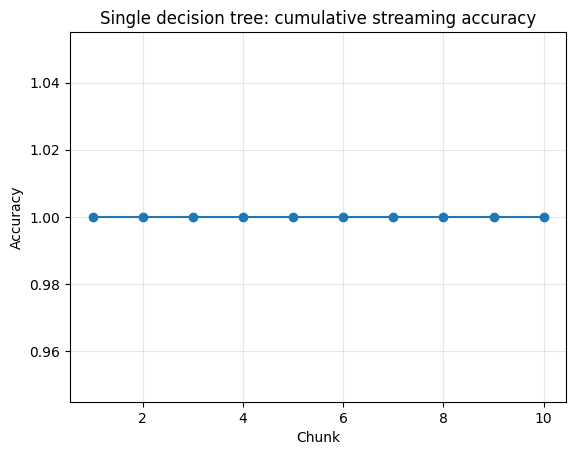

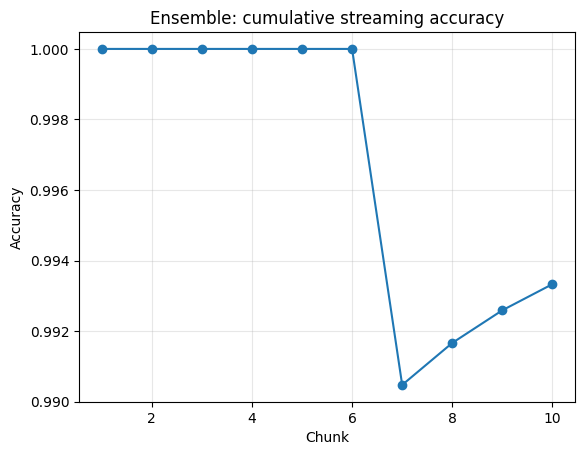

In [8]:
fig1 = plot_metric_over_time(
    single_trainer.logs["cumulative_accuracy"],
    title="Single decision tree: cumulative streaming accuracy",
    ylabel="Accuracy",
    show=False,
)
plt.show()

fig2 = plot_metric_over_time(
    ensemble_trainer.logs["cumulative_accuracy"],
    title="Ensemble: cumulative streaming accuracy",
    ylabel="Accuracy",
    show=False,
)
plt.show()

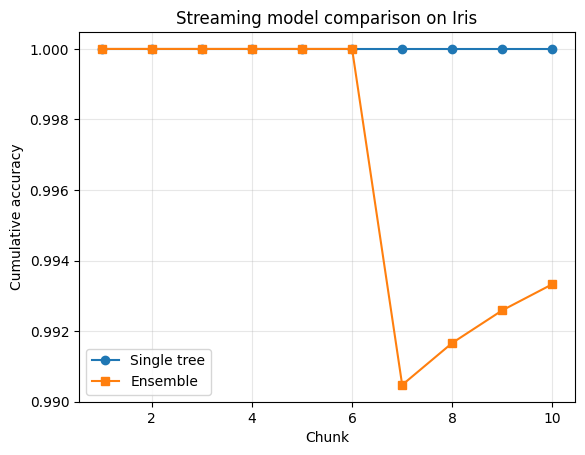

In [9]:
fig3 = compare_models(
    single_trainer.logs["cumulative_accuracy"],
    ensemble_trainer.logs["cumulative_accuracy"],
    labels=("Single tree", "Ensemble"),
    title="Streaming model comparison on Iris",
    ylabel="Cumulative accuracy",
    show=False,
)
plt.show()

## 8. Visualise latest predictions against ground truth

This cell compares the final stream chunk's true class IDs with the ensemble predictions.

Latest chunk true labels:       [2 2 0 2 0 0 1 0 2 2 0 2 0 1 2]
Latest chunk ensemble labels:   [2 2 0 2 0 0 1 0 2 2 0 2 0 1 2]
Class names: ['Iris-setosa' 'Iris-versicolor' 'Iris-virginica']


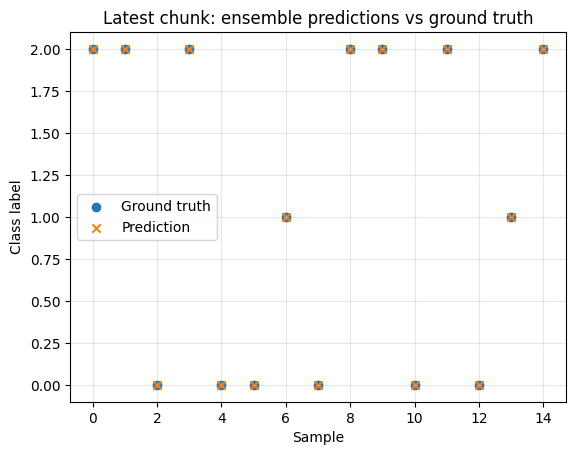

In [10]:
print("Latest chunk true labels:      ", latest_y_true)
print("Latest chunk ensemble labels:  ", latest_ensemble_pred)
print("Class names:", classes)

fig4 = plot_predictions_vs_ground_truth(
    latest_y_true,
    latest_ensemble_pred,
    title="Latest chunk: ensemble predictions vs ground truth",
    show=False,
)
plt.show()

## 9. Lightweight benchmark evidence

This quick table compares the average update time of the single tree and the ensemble during the streaming run. The ensemble is expected to be slower because it trains multiple trees, but it provides model averaging through majority vote.

Average update + score time
  Single decision tree: 28.08 ms per chunk
  Ensemble:             66.38 ms per chunk
  Relative cost:        2.36x


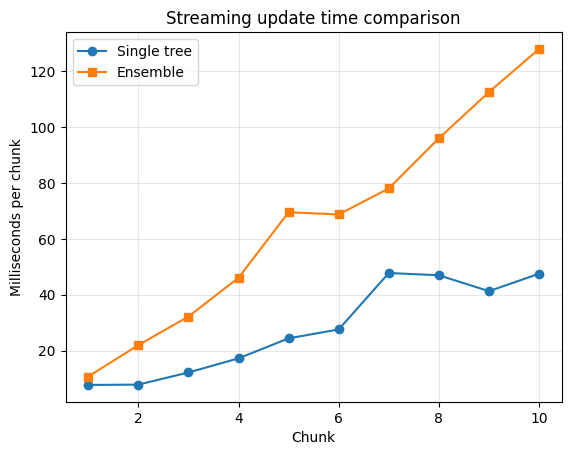

In [11]:
print("Average update + score time")
print(f"  Single decision tree: {np.mean(single_times):.2f} ms per chunk")
print(f"  Ensemble:             {np.mean(ensemble_times):.2f} ms per chunk")
print(f"  Relative cost:        {np.mean(ensemble_times) / np.mean(single_times):.2f}x")

fig5 = compare_models(
    single_times,
    ensemble_times,
    labels=("Single tree", "Ensemble"),
    title="Streaming update time comparison",
    ylabel="Milliseconds per chunk",
    show=False,
)
plt.show()

## 13. Running tests

The command below is commented out so the notebook does not unexpectedly run a full test suite. Uncomment it when running from the project root if `pytest` is installed.

In [14]:
!python -m pytest "$PROJECT_ROOT"/"tests"/*

============================= test session starts ==============================
platform linux -- Python 3.14.3, pytest-9.0.3, pluggy-1.6.0
rootdir: /mnt/d/Adelaide University/Semester 1/Programming for AI 1/Assignments/NumCompute
configfile: pyproject.toml
collected 230 items                                                            

../tests/test_benchmarking.py ........                                   [  3%]
../tests/test_edge_cases.py .......                                      [  6%]
../tests/test_ensemble.py ........                                       [ 10%]
../tests/test_io.py ........                                             [ 13%]
../tests/test_metrics.py ...............                                 [ 20%]
../tests/test_optim.py ..............                                    [ 26%]
../tests/test_pipeline.py ......                                         [ 28%]
../tests/test_pipeline_streaming.py ...                                  [ 30%]
../tests/test_prepro